# System identification of the voice coil actuator with magnetic end springs

This notebook walks through the identification of the actuator model step by step. Each phase has three parts: **what** we do, **how** we do it in Python, and **why** it is there. Run the cells in order. Every phase builds only on what the previous phase established, so if something looks wrong you know where to look.

## The model we are building towards

$$m\ddot{x} = K_f(x)\, i \;-\; c\,\dot{x} \;+\; F_s(x - x_0)$$

**Variables and parameters**

| Symbol | Unit | Meaning | Status |
|---|---|---|---|
| $t$ | s | Time | Measured, 2 kHz |
| $x$ | m | Position of the mover relative to the sensor zero | Measured (`position_mm`, derived from `ai1_value_V`) |
| $\dot{x}$ | m/s | Velocity of the mover | Derived from $x$ |
| $\ddot{x}$ | m/s² | Acceleration of the mover | Measured (`ai2_value_V`), also derived from $x$ as a cross check |
| $i$ | A | Coil current, the input to the system | Measured (`actual_current_A`) |
| $V$ | V | Coil terminal voltage | Not in this log, see Phase 0 |
| $m$ | kg | Moving mass, 51.5 kg | Known with certainty |
| $K_f(x)$ | N/A | Motor constant, force per ampere, may vary with position | To identify, datasheet 283 N/A at centre |
| $c$ | N·s/m | Viscous damping coefficient, mainly eddy current damping | To identify, datasheet 1160 N·s/m |
| $F_s(\cdot)$ | N | Restoring force of the magnetic end springs as a function of displacement from equilibrium | To identify, shape unknown |
| $x_0$ | m | Position of the spring equilibrium in sensor coordinates | To identify, expected near zero |
| $R$ | Ω | Coil resistance, 4.75 Ω | Datasheet |
| $L$ | H | Coil inductance, 16.5 mH | Datasheet |
| $r$ | N | Restoring force residual, the force left after motor and inertia are accounted for | Computed in Phase 3 |

**Reading the equation.** The left side is the force needed to accelerate the mass. The right side lists where that force comes from: the motor pushes with $K_f i$, the damper resists motion with $c\dot{x}$, and the magnetic springs push the mover back toward equilibrium with $F_s$. The sign convention is that $F_s$ is negative for positive displacement, so it always points back toward $x_0$.

Everything below serves one goal: determine $K_f(x)$, $c$, $F_s$ and $x_0$ from data in a way you can trust and defend.

**Guiding principle.** Go from simple and certain to complex and uncertain.

**Frequency separation.** Each force term dominates in its own frequency band, and the chirp sweeps through all of them in order.

| Frequency region | Dominant force | What you learn |
|---|---|---|
| Low (below ~4 Hz) | Spring $F_s(x)$ | Spring curve |
| Middle | Damping and spring interplay | Damping $c$ |
| High (above ~20 Hz) | Inertia $m\ddot{x}$ | Motor constant $K_f$ |

## Outline of this notebook

The notebook follows the identification plan phase by phase. Every phase starts with a text cell (what, how, why) followed by the code that carries it out. Cells marked with a flag such as `RUN_PHASE5` are slow and switched off until you choose to run them.

| Phase | Title | Purpose | Status |
|---|---|---|---|
| 0 | Get to know the data | Load the CSV, check time base and units, convert to SI, remove the accelerometer bias, document current tracking | Complete |
| 1 | Condition the signals | Derive velocity, zero phase filtering, accelerometer cross check | Complete |
| 2 | Motor constant from the tail | Estimate $K_f$ and a first $c$ where inertia dominates, back EMF check | Complete, back EMF part waits for a coil voltage log |
| 3 | Restoring force plot | Let the data draw the spring and damping without assuming a form | Complete |
| 4 | Least squares fit | Polynomial spring and $K_f(x)$, linear in the parameters, with uncertainties | Complete, physical magnet form still to add |
| 5 | Simulation based refinement | Output error fit with `solve_ivp` and `least_squares`, started from Phase 4 | Code present, run behind `RUN_PHASE5` |
| 6 | Validation | Held out segments, second amplitude, small signal frequency response | Code present, needs additional runs |
| 7 | Next experiments | What to measure next and why | Text only |

**How to use it.** Run top to bottom once with the defaults. Then go back to the decision points (accelerometer scale in Phase 1, the choice of $K_f$ at the end of Phase 2, the spring form in Phase 4) and adjust. Notes cells are provided after Phase 3 for writing down what the plots show.

**Settings that may need your attention** are all in the first code cell: file path, accelerometer sensitivity, chirp parameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import least_squares

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

# ---- settings you may need to adapt ----
CSV_PATH = "data/voice_coil_log_chirp_6.5A_1.0to55.0Hz_120.0s_20260923_160540.csv"

FS = 2000.0                 # sample rate in Hz, known and constant
M = 51.5                    # moving mass in kg, certain
KF_DATASHEET = 283.0        # N/A at centre
C_DATASHEET = 1160.0        # N s/m
R_COIL = 4.75               # ohm
L_COIL = 16.5e-3            # H
G = 9.81                    # m/s^2

# chirp parameters, read from the file name
F0, F1, T_CHIRP = 1.0, 55.0, 120.0

# accelerometer scaling, V per g. Source: the calibration in scripts/plot_voice_coil_log.py
# (AI2_G_SCALE = -17.29 g/V, i.e. 0.0578 V/g). The earlier value of 0.326 V/g was derived by
# dividing the 0.65 V rest voltage by the "2 g" that script prints at rest, which ignores the
# offset term of the affine calibration and is wrong by a factor of six.
# The data itself gives about 0.055 V/g at 8 to 20 Hz (Phase 1 cross check), so the two agree.
# Sign: the notebook keeps the accelerometer positive in the same direction as position, which
# the cross check slope confirms; the plot script uses the opposite sign convention.
ACC_SCALE_V_PER_G = 0.0578

def chirp_freq(t):
    "Instantaneous frequency of the logarithmic chirp at time t (Hz)."
    return F0 * (F1 / F0) ** (t / T_CHIRP)

def time_at_freq(f):
    "Inverse: time at which the chirp passes frequency f (s)."
    f = np.maximum(f, 1e-9)
    return T_CHIRP * np.log(f / F0) / np.log(F1 / F0)

print(f"20 Hz is reached at t = {time_at_freq(20):.1f} s, 4 Hz at t = {time_at_freq(4):.1f} s")

20 Hz is reached at t = 89.7 s, 4 Hz at t = 41.5 s


## Phase 0: Get to know the data

**What.** Load the CSV, confirm the time base is consistent with the known 2 kHz rate, check the units of every column and convert everything to SI.

**Current tracking.** You have established that the actual current follows the target almost 1:1. We still plot the difference and the amplitude ratio as a function of frequency. It costs nothing and documents the fact for the report. From here on the measured actual current is the input $i$ in every step.

**Why the unit conversion here.** Every later step mixes position, acceleration and current in one equation. A single factor of 1000 from mm to m, or 9.81 from g to m/s², would silently corrupt every fitted parameter. Doing the conversion once, in one place, and checking it once, removes that risk for the rest of the project.

**Accelerometer bias.** The accelerometer output sits around 0.65 V when the mover is at rest, which is the sensor's zero-g output plus any gravity component along its axis. We subtract the mean of the whole run. This is exact rather than approximate: the mean acceleration over a run equals the net change in velocity divided by the run length, and the mover starts and ends at rest, so the true mean is zero and whatever mean the sensor reports is bias.

**Laser range.** The position sensor covers 35 to 85 mm, which after the centre offset is about +16.7 mm to −33 mm. The positive travel of the mover exceeds that, and whenever it does the sensor emits an error current that the firmware still converts to a position, giving a constant fake value near +19.7 mm. Phase 0 flags these samples and Phase 1 turns the flag into a validity mask that the later phases use.

**A note on the 2 kHz rate.** The Nyquist frequency is 1000 Hz, about twenty times the highest excitation frequency. That leaves a wide, clean band between 55 Hz and 1000 Hz in which to place the low pass filter of Phase 1.

**About the logged columns.** The file contains `ai1_value_V` (position sensor voltage), `position_mm` (the same signal converted to mm), `ai2_value_V` (accelerometer voltage), the three current signals, the DC bus voltage, and `power_W` and `energy_J`. There is no coil voltage column, so the back EMF cross check in Phase 2 needs the coil voltage to be logged in a future run.

In [2]:
raw = pd.read_csv(CSV_PATH)
raw.columns = [c.strip() for c in raw.columns]      # some headers carry a leading space
print(raw.columns.tolist())
print(f"{len(raw)} rows")
raw.describe().T[["mean", "min", "max"]]

['time_s', 'actual_current_A', 'target_current_A', 'demand_current_A', 'ai1_value_V', 'ai2_value_V', 'dc_bus_voltage_V', 'power_W', 'energy_J', 'cycle_jitter_us', 'pdo_exchange_us', 'position_mm']
240001 rows


,mean,min,max
time_s,59.999500,0.000000,119.999500
actual_current_A,0.006156,-7.126465,7.133789
target_current_A,0.008551,-6.500244,6.500244
demand_current_A,0.005849,-6.503906,6.496582
ai1_value_V,4.714435,1.439209,7.816162
ai2_value_V,0.652943,0.477295,0.828857
dc_bus_voltage_V,538.944629,525.019226,544.248505
power_W,2063.585280,0.000000,3836.503522
energy_J,128344.262519,0.000000,247630.810011
cycle_jitter_us,-459.373566,-464.200000,-406.100000


In [3]:
# --- time base check ---
t = raw["time_s"].to_numpy()
dt = np.diff(t)
print("unique time steps (ms) and counts:", np.unique(np.round(dt * 1e3, 3), return_counts=True))
# The very first two rows share t = 0; drop the duplicate so the grid is uniform.
raw = raw.iloc[1:].reset_index(drop=True)
t = raw["time_s"].to_numpy()
print(f"after dropping duplicate: {len(raw)} rows, dt = {np.median(np.diff(t))*1e3:.3f} ms, implied fs = {1/np.median(np.diff(t)):.1f} Hz")

unique time steps (ms) and counts: (array([0. , 0.5]), array([     1, 239999]))
after dropping duplicate: 240000 rows, dt = 0.500 ms, implied fs = 2000.0 Hz


In [4]:
# --- position sensor scaling: position_mm should be an affine function of ai1_value_V ---
A = np.c_[raw["ai1_value_V"], np.ones(len(raw))]
coef = np.linalg.lstsq(A, raw["position_mm"], rcond=None)[0]
resid = A @ coef - raw["position_mm"]
print(f"position_mm = {coef[0]:.4f} * ai1_V + {coef[1]:.4f}   (max residual {np.abs(resid).max():.2e} mm)")
print(f"position range: {raw['position_mm'].min():.2f} to {raw['position_mm'].max():.2f} mm")

# --- laser range check ---
# The ILD1220-50 outputs 4 to 20 mA over 35 to 85 mm and an error current of about 3 mA when the
# target is outside that range. Through the ~476 ohm shunt (main.h) 4 mA is 1.90 V. Below that the
# logged position is not a measurement: it is the error current converted as if it were a distance.
LASER_R_SHUNT = 476.0                              # ohm
LASER_V_MIN = 4e-3 * LASER_R_SHUNT * 1.02          # 2 % margin above the 4 mA lower range limit
laser_ok = (raw["ai1_value_V"] >= LASER_V_MIN).to_numpy()
X_LASER_LIMIT = (coef[0] * LASER_V_MIN + coef[1]) * 1e-3    # m, position at which the laser runs out of range
print(f"laser current {raw['ai1_value_V'].min()/LASER_R_SHUNT*1e3:.2f} to {raw['ai1_value_V'].max()/LASER_R_SHUNT*1e3:.2f} mA "
      f"(range is 4 to 20 mA); {(~laser_ok).sum()} samples ({100*(~laser_ok).mean():.1f} %) are below 4 mA")
print(f"the laser runs out of range at x = {X_LASER_LIMIT*1e3:+.2f} mm; beyond that position_mm is frozen at "
      f"{raw['position_mm'].max():.2f} mm and the true position is unknown")


position_mm = -6.5680 * ai1_V + 29.2000   (max residual 5.11e-05 mm)
position range: -22.14 to 19.75 mm


In [5]:
# --- build the SI dataframe used by every later phase ---
# Accelerometer bias: the run mean of the raw voltage. The mover starts and ends at rest, so the
# true mean acceleration is zero and the reported mean is entirely sensor offset (see Phase 0 text).
ACC_BIAS_V = raw["ai2_value_V"].mean()
print(f"accelerometer bias removed: {ACC_BIAS_V:.4f} V  ({ACC_BIAS_V / ACC_SCALE_V_PER_G:.3f} g at the current scale setting)")

df = pd.DataFrame({
    "t":      t,
    "f_inst": chirp_freq(t),                                   # instantaneous chirp frequency, Hz
    "i":      raw["actual_current_A"].to_numpy(),              # A
    "i_tgt":  raw["target_current_A"].to_numpy(),              # A
    "x":      raw["position_mm"].to_numpy() * 1e-3,            # m
    "a_meas": (raw["ai2_value_V"].to_numpy() - ACC_BIAS_V) / ACC_SCALE_V_PER_G * G,   # m/s^2, bias removed
    "v_bus":  raw["dc_bus_voltage_V"].to_numpy(),              # V
    "p_log":  raw["power_W"].to_numpy(),                       # W as logged
    "laser_ok": laser_ok,                                      # True where the laser is inside its range
})
df.head()

accelerometer bias removed: 0.6529 V  (11.297 g at the current scale setting)


,t,f_inst,i,i_tgt,x,a_meas,v_bus,p_log
0,0.0000,1.000000,0.000000,0.000000,-0.000289,0.022508,543.485870,0.000000
1,0.0005,1.000017,-0.007324,0.000000,-0.000273,-1.634839,543.322449,3.979412
2,0.0010,1.000033,0.021973,0.020142,-0.000249,-0.806250,543.213501,11.935844
3,0.0015,1.000050,0.000000,0.020142,-0.000265,0.851267,543.104553,0.000000
4,0.0020,1.000067,0.000000,0.020142,-0.000265,0.851267,543.104553,0.000000


**Look at the raw signals before doing anything with them.** Two views: the whole run, so the envelope of every signal is visible against the chirp frequency, and three short windows (low, mid and high frequency) where individual cycles can be seen. The accelerometer is shown in volts with the bias subtracted, not in m/s², because its scale factor is only confirmed in Phase 1.

Things to check by eye: the position amplitude should shrink as frequency rises (the mover cannot follow at high frequency), there should be no clipping or flat tops on any trace, the position should not touch the end stops, and the accelerometer should not saturate. Any of those would mean the run is not usable as is.

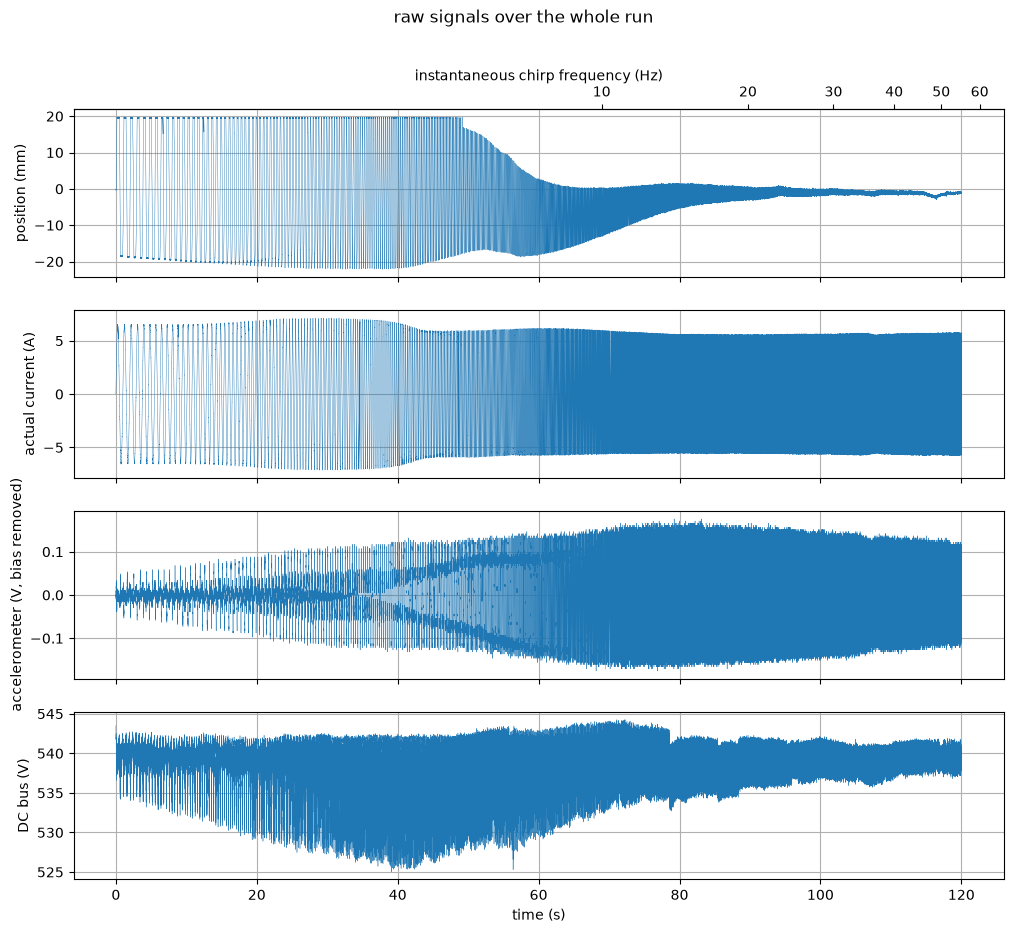

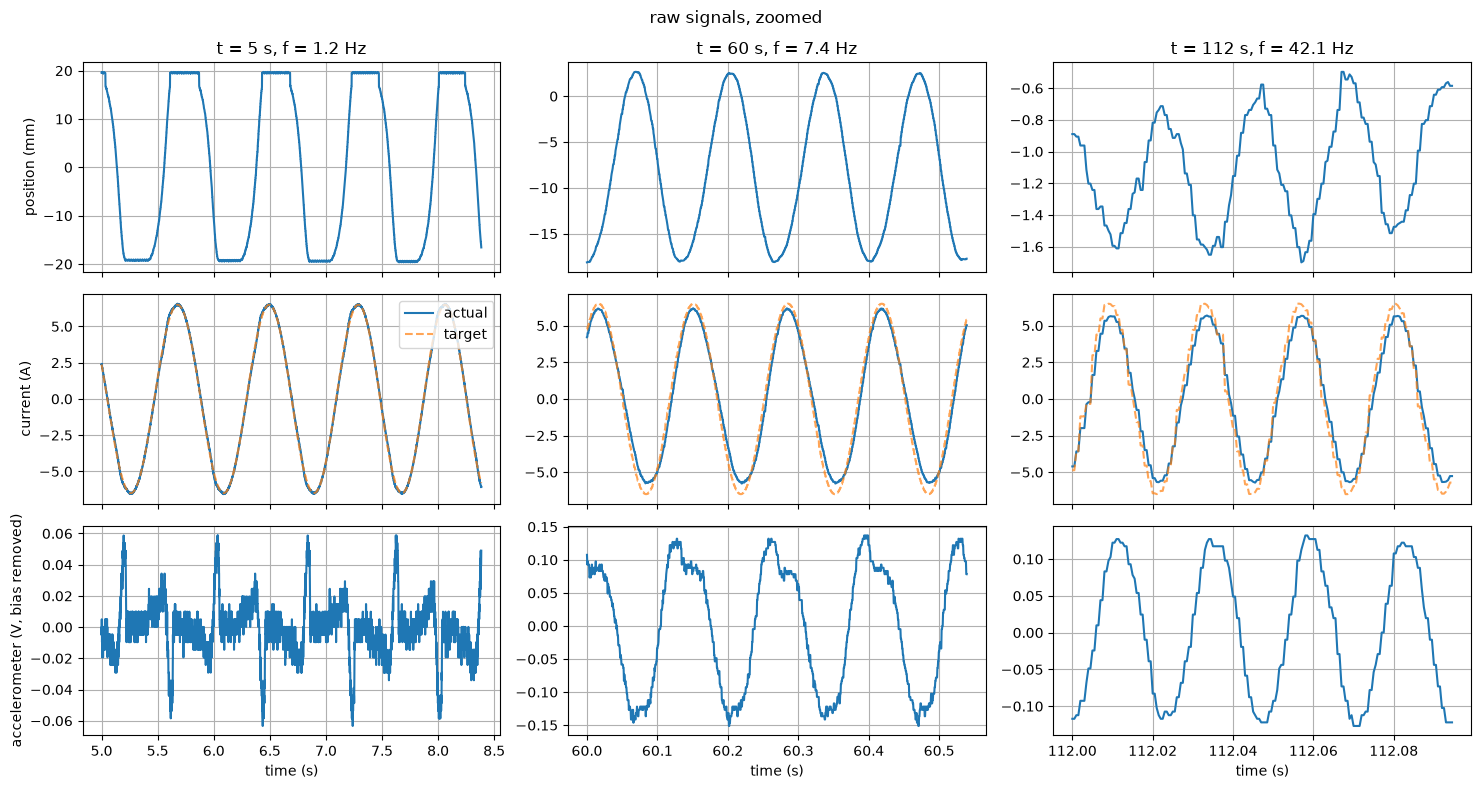

In [6]:
# --- raw signal overview: whole run ---
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
ax[0].plot(df.t, df.x * 1e3, lw=0.3);                 ax[0].set_ylabel("position (mm)")
ax[1].plot(df.t, df.i, lw=0.3);                       ax[1].set_ylabel("actual current (A)")
ax[2].plot(df.t, raw["ai2_value_V"] - ACC_BIAS_V, lw=0.3);   ax[2].set_ylabel("accelerometer (V, bias removed)")
ax[3].plot(df.t, df.v_bus, lw=0.3);                   ax[3].set_ylabel("DC bus (V)"); ax[3].set_xlabel("time (s)")
secax = ax[0].secondary_xaxis("top", functions=(chirp_freq, time_at_freq))
secax.set_xlabel("instantaneous chirp frequency (Hz)")
fig.suptitle("raw signals over the whole run")
plt.show()

# --- raw signal overview: zoom on three windows ---
# Each window spans about four cycles of the instantaneous chirp frequency, so the waveform
# shape is visible at low, mid and high frequency alike.
ZOOM_STARTS = [5.0, 60.0, 112.0]      # s, adjust to taste
N_CYCLES = 4
fig, ax = plt.subplots(3, len(ZOOM_STARTS), figsize=(15, 8), sharex="col")
for col, t0 in enumerate(ZOOM_STARTS):
    span = N_CYCLES / chirp_freq(t0)
    mask = (df.t >= t0) & (df.t < t0 + span)
    ax[0, col].plot(df.t[mask], df.x[mask] * 1e3)
    ax[1, col].plot(df.t[mask], df.i[mask], label="actual")
    ax[1, col].plot(df.t[mask], df.i_tgt[mask], "--", alpha=0.7, label="target")
    ax[2, col].plot(df.t[mask], raw["ai2_value_V"][mask] - ACC_BIAS_V)
    ax[0, col].set_title(f"t = {t0:.0f} s, f = {chirp_freq(t0):.1f} Hz")
    ax[2, col].set_xlabel("time (s)")
ax[0, 0].set_ylabel("position (mm)")
ax[1, 0].set_ylabel("current (A)"); ax[1, 0].legend(loc="upper right")
ax[2, 0].set_ylabel("accelerometer (V, bias removed)")
fig.suptitle("raw signals, zoomed")
plt.tight_layout()
plt.show()


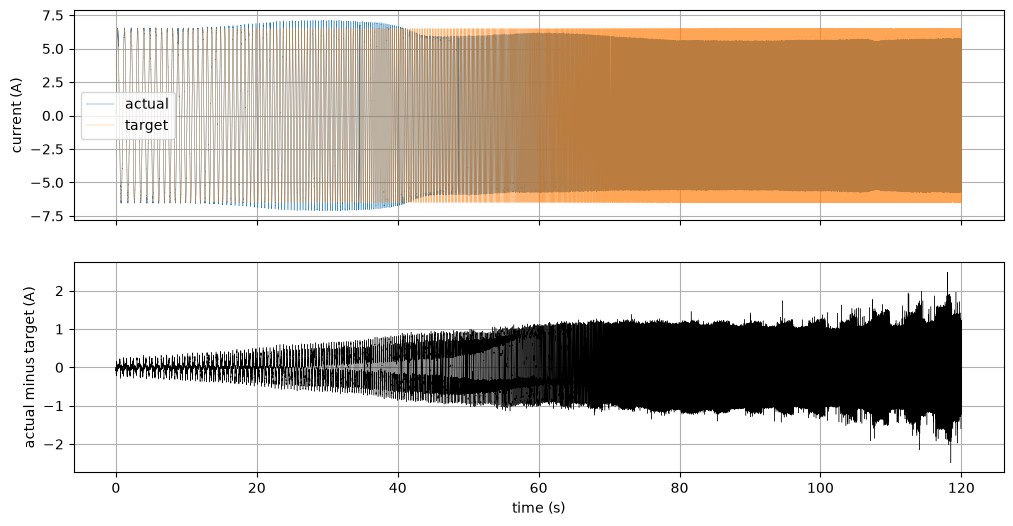

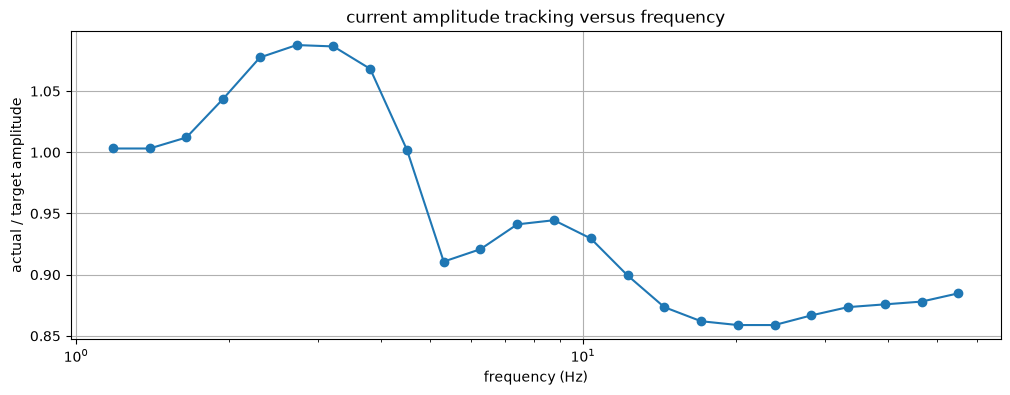

,t_start,t_end,f_start,f_end,amp_actual,amp_target,ratio
0,0.0,5.0,1.000,1.182,6.519,6.498,1.003
1,5.0,10.0,1.182,1.396,6.519,6.498,1.003
2,10.0,15.0,1.396,1.650,6.577,6.498,1.012
3,15.0,20.0,1.650,1.950,6.782,6.498,1.044
4,20.0,25.0,1.950,2.304,7.002,6.498,1.077
5,25.0,30.0,2.304,2.723,7.068,6.498,1.088
6,30.0,35.0,2.723,3.218,7.061,6.498,1.087
7,35.0,40.0,3.218,3.803,6.943,6.500,1.068
8,40.0,45.0,3.803,4.494,6.511,6.498,1.002
9,45.0,50.0,4.494,5.311,5.918,6.498,0.911


In [7]:
# --- current tracking: difference over time and amplitude ratio per frequency band ---
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(df.t, df.i, lw=0.3, label="actual")
ax[0].plot(df.t, df.i_tgt, lw=0.3, label="target", alpha=0.7)
ax[0].set_ylabel("current (A)"); ax[0].legend()
ax[1].plot(df.t, df.i - df.i_tgt, lw=0.3, color="k")
ax[1].set_ylabel("actual minus target (A)"); ax[1].set_xlabel("time (s)")
plt.show()

# amplitude ratio per 5 s window, using the 99th percentile as a robust amplitude estimate
edges = np.arange(0, T_CHIRP + 1, 5)
rows = []
for a, b in zip(edges[:-1], edges[1:]):
    mask = (df.t >= a) & (df.t < b)
    rows.append((a, b, chirp_freq(a), chirp_freq(b),
                 np.percentile(np.abs(df.i[mask]), 99), np.percentile(np.abs(df.i_tgt[mask]), 99)))
track = pd.DataFrame(rows, columns=["t_start", "t_end", "f_start", "f_end", "amp_actual", "amp_target"])
track["ratio"] = track.amp_actual / track.amp_target
plt.plot(track.f_end, track.ratio, "o-")
plt.xscale("log"); plt.xlabel("frequency (Hz)"); plt.ylabel("actual / target amplitude")
plt.title("current amplitude tracking versus frequency"); plt.show()
track.round(3)

**Interpretation.** If the ratio stays near 1 across the whole band, the current loop is transparent and the demand could have served as input. If the ratio drops toward the high end, the current loop is bandwidth limited at those frequencies. Either way we continue with the measured actual current, so the identification is unaffected. The result does matter for how much force is really available at 50 Hz in later control design.

In [8]:
# --- power column check ---
# The logged power should equal coil voltage times current. Since the coil voltage is not logged
# we can only compare it against the DC bus voltage times |i|, which is an upper bound on what
# the drive can deliver. If the two agree exactly, the logged power is bus power, not coil power.
ratio = df.p_log / (np.abs(df.i) * df.v_bus)
ratio = ratio.replace([np.inf, -np.inf], np.nan).dropna()
print(f"median of power_W / (|i| * V_bus) = {ratio.median():.6f}")
print(f"copper loss estimate I_rms^2 R = {np.mean(df.i**2) * R_COIL:.1f} W  versus logged mean power {df.p_log.mean():.1f} W")

median of power_W / (|i| * V_bus) = 1.000000
copper loss estimate I_rms^2 R = 86.9 W  versus logged mean power 2063.6 W


## Phase 1: Condition the signals

**What.**

1. Compute velocity $\dot{x}$ from position by differentiation, not by integrating acceleration.
2. Low pass filter position, velocity, acceleration and current with the **same** zero phase filter, cutoff around 100 Hz.

**How.** `scipy.signal.butter` designs a Butterworth filter and `scipy.signal.filtfilt` applies it forwards and backwards, which cancels the time delay a normal filter introduces. Differentiation is done with `numpy.gradient` after filtering.

**Why differentiate rather than integrate.** Integrating acceleration adds up every small error, so the result drifts away without bound. Differentiating position only amplifies high frequency noise, which the low pass filter removes. Drift is the worse enemy here.

**Why the same filter on every signal.** Newton's law must hold at each instant. If position is delayed by 3 ms and current is not, the balance computed in Phase 3 is between forces from different moments, and the damping estimate in particular gets biased. Identical zero phase filtering keeps all signals aligned.

**Why 100 Hz.** About twice the highest excitation frequency, so no signal content is lost, and a tenth of the Nyquist frequency, so differentiation noise is suppressed thoroughly.

**Validity mask.** The laser range flag from Phase 0 becomes `df.valid` here, widened by a short guard on both sides of every out of range interval. The guard matters: a frozen position has a kink at each end, and after zero phase filtering and two differentiations that kink becomes an acceleration spike of tens of g spread over some milliseconds. Those spikes are not physics and must not reach the force balance.

**Cross check.** Differentiating the filtered position twice gives an acceleration that is independent of the accelerometer. Comparing it with the measured acceleration tests the sensor scaling, the filtering and the sample rate in one go. We also use this comparison to estimate the accelerometer scale factor from the data, which either confirms `ACC_SCALE_V_PER_G` or tells us to change it.

In [9]:
F_CUT = 100.0     # Hz
b, a = signal.butter(4, F_CUT / (FS / 2))
lp = lambda s: signal.filtfilt(b, a, s)

df["x_f"] = lp(df.x)
df["i_f"] = lp(df.i)
df["v_f"] = np.gradient(df.x_f, 1 / FS)
df["a_x"] = np.gradient(df.v_f, 1 / FS)               # acceleration derived from position
df["a_f"] = lp(df.a_meas)                             # measured acceleration, bias removed in Phase 0, filtered

# --- validity mask ---
# Where the laser is out of range the position is frozen, so the filtered position has a kink at
# each entry and exit. The zero phase filter and the two differentiations spread that kink over the
# filter's impulse response, so the mask is widened by GUARD_S on both sides. Later phases use df.valid.
GUARD_S = 0.025                                   # s, comfortably longer than the 4th order 100 Hz filter settles
n_guard = int(GUARD_S * FS)
bad = (~df.laser_ok.to_numpy()).astype(float)
bad = np.convolve(bad, np.ones(2 * n_guard + 1), mode="same") > 0
df["valid"] = ~bad
print(f"valid samples: {100*df.valid.mean():.1f} %  (laser out of range {100*(~df.laser_ok).mean():.1f} %, "
      f"plus a {GUARD_S*1e3:.0f} ms guard on each side of every such interval)")


a_measured ≈ 0.733 * a_from_position + 0.122
If the accelerometer scaling were right this slope would be 1.0.
Implied accelerometer scale: 0.0423 V/g  (current setting 0.0578 V/g)


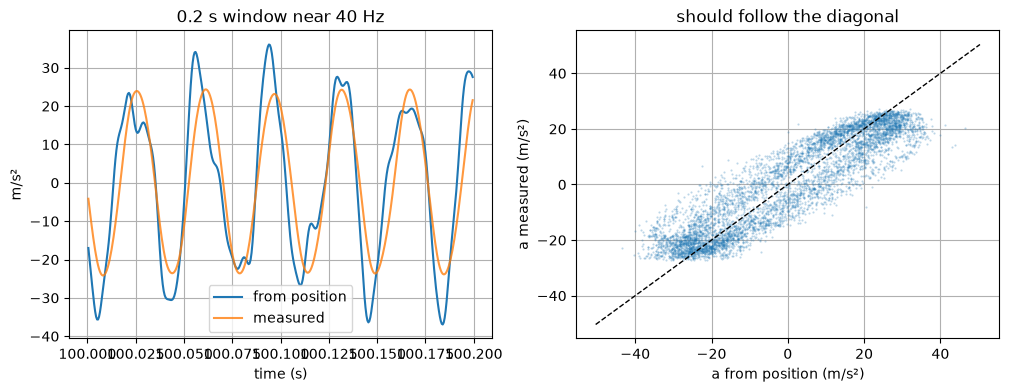

In [10]:
# --- cross check: measured acceleration versus acceleration from position ---
# Use the second half of the run where the motion is well above the noise floor.
mask = df.t > 60
A = np.c_[df.a_x[mask], np.ones(mask.sum())]
k, _, _, _ = np.linalg.lstsq(A, df.a_f[mask], rcond=None)
print(f"a_measured ≈ {k[0]:.3f} * a_from_position + {k[1]:.3f}")
print(f"If the accelerometer scaling were right this slope would be 1.0.")
print(f"Implied accelerometer scale: {ACC_SCALE_V_PER_G * k[0]:.4f} V/g  (current setting {ACC_SCALE_V_PER_G} V/g)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
seg = (df.t > 100) & (df.t < 100.2)
ax[0].plot(df.t[seg], df.a_x[seg], label="from position")
ax[0].plot(df.t[seg], df.a_f[seg], label="measured", alpha=0.8)
ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("m/s²"); ax[0].legend(); ax[0].set_title("0.2 s window near 40 Hz")
ax[1].plot(df.a_x[mask][::20], df.a_f[mask][::20], ".", ms=1, alpha=0.3)
lim = np.abs(df.a_x[mask]).max()
ax[1].plot([-lim, lim], [-lim, lim], "k--", lw=1)
ax[1].set_xlabel("a from position (m/s²)"); ax[1].set_ylabel("a measured (m/s²)"); ax[1].set_title("should follow the diagonal")
plt.show()

**Decision point.** If the slope above is close to 1 and the scatter hugs the diagonal, both acceleration signals are trustworthy and can be used interchangeably. If the slope is clearly not 1 but the scatter is tight, the accelerometer scale factor is simply wrong; correct `ACC_SCALE_V_PER_G` and rerun. If the scatter is wide, the accelerometer picks up something the position sensor does not (mount vibration, noise), and we prefer the position derived acceleration `a_x` for the rest of the analysis.

The variable `A_USE` below selects which acceleration the following phases use.

In [11]:
A_USE = "a_x"     # "a_x" (from position) or "a_f" (measured accelerometer)
df["a_use"] = df[A_USE]
print("using", A_USE)

using a_x


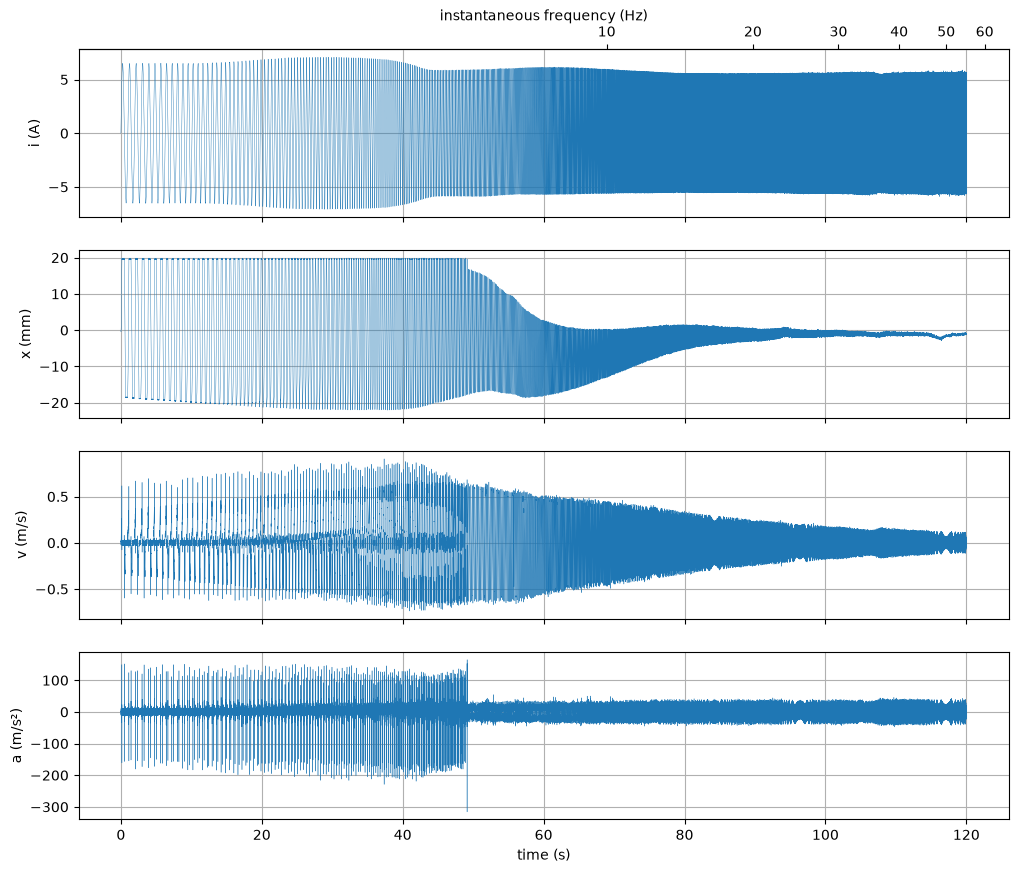

In [12]:
# --- overview of the conditioned signals ---
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
ax[0].plot(df.t, df.i_f, lw=0.3); ax[0].set_ylabel("i (A)")
ax[1].plot(df.t, df.x_f * 1e3, lw=0.3); ax[1].set_ylabel("x (mm)")
ax[2].plot(df.t, df.v_f, lw=0.3); ax[2].set_ylabel("v (m/s)")
ax[3].plot(df.t, df.a_use, lw=0.3); ax[3].set_ylabel("a (m/s²)"); ax[3].set_xlabel("time (s)")
secax = ax[0].secondary_xaxis("top", functions=(chirp_freq, time_at_freq))
secax.set_xlabel("instantaneous frequency (Hz)")
plt.show()

## Phase 2: Motor constant from the high frequency tail

**What.** Take the part of the chirp above about 20 Hz and solve, by least squares,

$$m\ddot{x} = K_f\, i - c\,\dot{x}$$

for the two unknowns $K_f$ and $c$.

**How.** Build a matrix with columns $[\,i,\ -\dot{x}\,]$ and a vector $m\ddot{x}$, and call `numpy.linalg.lstsq`.

**Why this works here.** At high frequency the mover barely displaces (under 1 mm), so the spring force is tiny and $K_f(x)$ is essentially constant at its centre value. Two terms drop out of the equation, leaving something simple and well conditioned. You get your first hard number with almost no assumptions.

**Why solve for $c$ at the same time.** With the datasheet damping, $c/(m\omega)$ is about 12% at 30 Hz, so ignoring damping would bias $K_f$ by that amount. Including it as a second unknown removes the bias at no cost.

**Cross check with the coil voltage.** In a run where the coil voltage is logged, the back EMF

$$V - R\,i - L\frac{di}{dt} = K_f\,\dot{x}$$

gives a completely independent estimate of $K_f$ through the electrical side. The code for it is included below but skipped when no coil voltage column exists.

**Sanity target.** The datasheet says 283 N/A at centre.

In [13]:
F_TAIL = 20.0                      # Hz, start of the "mass line" region
mask = df.f_inst > F_TAIL
print(f"tail window: t > {time_at_freq(F_TAIL):.1f} s, {mask.sum()} samples, "
      f"max |x| in window = {np.abs(df.x_f[mask]).max()*1e3:.2f} mm")

A = np.c_[df.i_f[mask], -df.v_f[mask]]
y = M * df.a_use[mask]
theta, res, rank, sv = np.linalg.lstsq(A, y, rcond=None)
Kf_tail, c_tail = theta

# standard errors of the coefficients
dof = len(y) - A.shape[1]
sigma2 = np.sum((A @ theta - y) ** 2) / dof
cov = sigma2 * np.linalg.inv(A.T @ A)
se = np.sqrt(np.diag(cov))
print(f"K_f = {Kf_tail:.1f} ± {se[0]:.1f} N/A   (datasheet {KF_DATASHEET})")
print(f"c   = {c_tail:.1f} ± {se[1]:.1f} N s/m  (datasheet {C_DATASHEET})")

# with c fixed at the datasheet value, K_f alone
Kf_fixed_c = np.linalg.lstsq(df.i_f[mask].to_numpy()[:, None], (y + C_DATASHEET * df.v_f[mask]).to_numpy(), rcond=None)[0][0]
print(f"K_f with c fixed at datasheet value: {Kf_fixed_c:.1f} N/A")

tail window: t > 89.7 s, 60584 samples, max |x| in window = 3.18 mm
K_f = 256.2 ± 0.4 N/A   (datasheet 283.0)
c   = 197.4 ± 14.2 N s/m  (datasheet 1160.0)
K_f with c fixed at datasheet value: 256.7 N/A


**How to read this.** The standard errors describe only the random scatter, not systematic effects such as a wrong accelerometer scale, so treat them as a lower bound on the uncertainty. A $c$ estimate far from the datasheet value is not alarming at this stage; in the tail the damping force is small compared with the inertial force, so $c$ is weakly determined here. It is determined much better in Phases 3 and 4 where velocities are large.

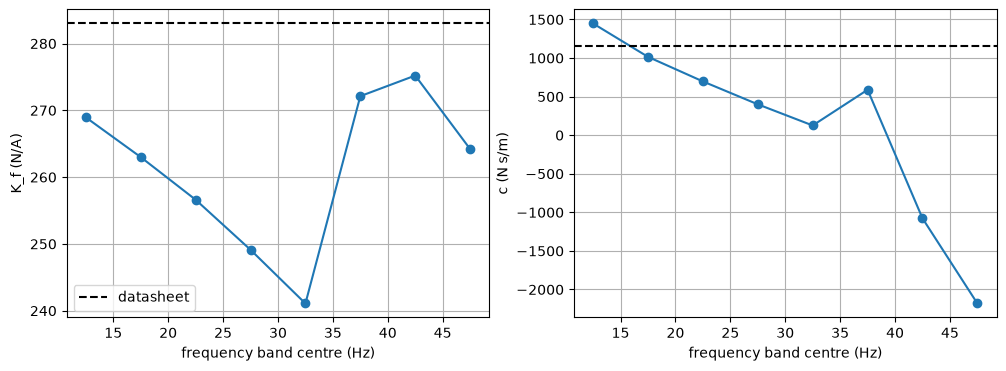

In [14]:
# --- K_f as a function of frequency, to see whether the estimate is stable across the tail ---
rows = []
for f_lo in np.arange(10, F1 - 5, 5):
    mk = (df.f_inst > f_lo) & (df.f_inst <= f_lo + 5)
    Aw = np.c_[df.i_f[mk], -df.v_f[mk]]
    th = np.linalg.lstsq(Aw, M * df.a_use[mk], rcond=None)[0]
    rows.append((f_lo, f_lo + 5, th[0], th[1]))
kf_vs_f = pd.DataFrame(rows, columns=["f_lo", "f_hi", "Kf", "c"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(kf_vs_f.f_lo + 2.5, kf_vs_f.Kf, "o-"); ax[0].axhline(KF_DATASHEET, color="k", ls="--", label="datasheet")
ax[0].set_xlabel("frequency band centre (Hz)"); ax[0].set_ylabel("K_f (N/A)"); ax[0].legend()
ax[1].plot(kf_vs_f.f_lo + 2.5, kf_vs_f.c, "o-"); ax[1].axhline(C_DATASHEET, color="k", ls="--")
ax[1].set_xlabel("frequency band centre (Hz)"); ax[1].set_ylabel("c (N s/m)")
plt.show()

In [15]:
# --- back EMF cross check (only runs when a coil voltage column is present) ---
if "coil_voltage_V" in raw.columns:
    v_coil = lp(raw["coil_voltage_V"].to_numpy())
    di_dt = np.gradient(df.i_f, 1 / FS)
    emf = v_coil - R_COIL * df.i_f - L_COIL * di_dt
    mk = df.f_inst > F_TAIL
    Kf_emf = np.linalg.lstsq(df.v_f[mk].to_numpy()[:, None], emf[mk], rcond=None)[0][0]
    print(f"K_f from back EMF: {Kf_emf:.1f} N/A   (mechanical route gave {Kf_tail:.1f})")
else:
    print("No coil voltage column in this log. Log the coil voltage in the next run to enable this cross check.")

No coil voltage column in this log. Log the coil voltage in the next run to enable this cross check.


In [16]:
KF = Kf_tail     # value carried into the next phases; overwrite by hand if you prefer another estimate
print(f"carrying K_f = {KF:.1f} N/A into Phase 3")

carrying K_f = 256.2 N/A into Phase 3


## Phase 3: Restoring force plot

**What.** Using $K_f$ from Phase 2, compute the leftover force for the whole run:

$$r(t) = K_f\, i(t) - m\,\ddot{x}(t) \quad (= c\,\dot{x} - F_s(x - x_0))$$

and plot it against position, against velocity, and over the $(x, \dot{x})$ plane.

**Why this is the central step.** Until now we had a guess about the spring's shape. This plot lets the data draw the spring. Nothing about the spring's form has been assumed. Look for:

* **A steep wall at the negative end, near −20 mm.** Confirms that the flat position envelope in the first part of the run is the spring stiffening, as expected from repelling magnets whose force rises sharply as the gap closes. The positive wall cannot be seen: the laser runs out of range at about +16.7 mm, and everything beyond is masked out.
* **Symmetry.** Over the range where both sides are measured, the spring curve should be odd, $F_s(-x) = -F_s(x)$. The mirrored overlay below tests this directly. A mismatch means the equilibrium sits at some $x_0 \neq 0$, or the two end magnet pairs differ.
* **Loop width.** The damping term $c\dot{x}$ smears the curve into a loop around the spring line, wider where velocity is higher. A loop that does not shrink at low velocity signals dry friction, which the current model does not have.
* **Dependence on frequency.** If the curves from different frequency bands lie on top of each other, the spring is a pure function of position. If they separate, something frequency dependent is missing.

**Why some points are grey.** Samples inside the validity mask from Phase 1 are shown in grey and take no part in any estimate. Their $r$ values reach ±15 000 N, which is thirty g on a 51.5 kg mass, and comes entirely from differentiating the frozen laser output. The axes are scaled to the valid data so the spring is visible.

**Why colour by frequency.** Because the chirp sweeps frequency, time is frequency. Colour shows at a glance which frequency region produced which part of the picture.

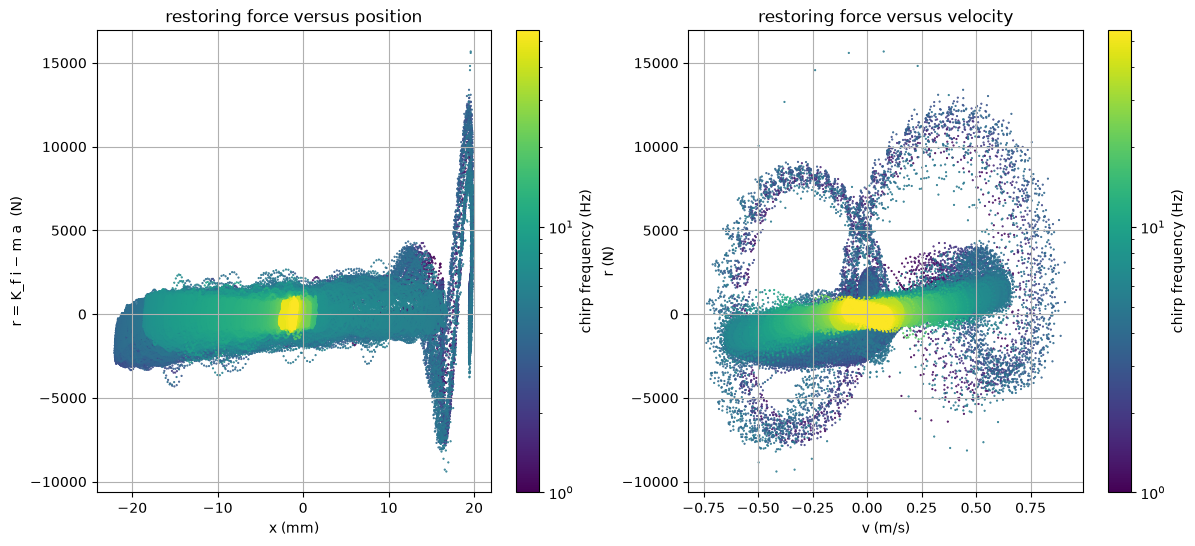

In [17]:
df["r"] = KF * df.i_f - M * df.a_use      # N
ok = df.valid.to_numpy()
r_lim = 1.1 * np.percentile(np.abs(df.r[ok]), 99.9)
print(f"{(~ok).sum()} samples masked out. |r| reaches {np.abs(df.r[~ok]).max():.0f} N on masked samples "
      f"versus {np.abs(df.r[ok]).max():.0f} N on valid ones; axes are limited to ±{r_lim:.0f} N")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, xdata, xlabel in [(ax[0], df.x_f * 1e3, "x (mm)"), (ax[1], df.v_f, "v (m/s)")]:
    a.scatter(xdata[~ok], df.r[~ok], s=0.3, color="lightgrey", label="masked (laser out of range)")
    sc = a.scatter(xdata[ok], df.r[ok], c=df.f_inst[ok], s=0.3, cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
    a.set_xlabel(xlabel); a.set_ylabel("r = K_f i − m a  (N)"); a.set_ylim(-r_lim, r_lim)
    plt.colorbar(sc, ax=a, label="chirp frequency (Hz)")
ax[0].axvline(X_LASER_LIMIT * 1e3, color="r", ls="--", lw=1, label="laser range limit")
ax[0].legend(loc="upper left", markerscale=10)
ax[0].set_title("restoring force versus position"); ax[1].set_title("restoring force versus velocity")
plt.show()

# --- the same quantity over time, to see where the large values come from ---
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(df.t, df.x_f * 1e3, lw=0.3, color="k")
ax[0].axhline(X_LASER_LIMIT * 1e3, color="r", ls="--", lw=1, label="laser range limit")
ax[0].fill_between(df.t, -25, 25, where=~ok, color="red", alpha=0.15, label="masked")
ax[0].set_ylabel("x (mm)"); ax[0].set_ylim(-25, 25); ax[0].legend(loc="lower right")
ax[1].plot(df.t, df.r, lw=0.3, color="k")
ax[1].set_ylabel("r (N)"); ax[1].set_ylim(-r_lim, r_lim); ax[1].set_xlabel("time (s)")
secax = ax[0].secondary_xaxis("top", functions=(chirp_freq, time_at_freq))
secax.set_xlabel("instantaneous frequency (Hz)")
plt.show()


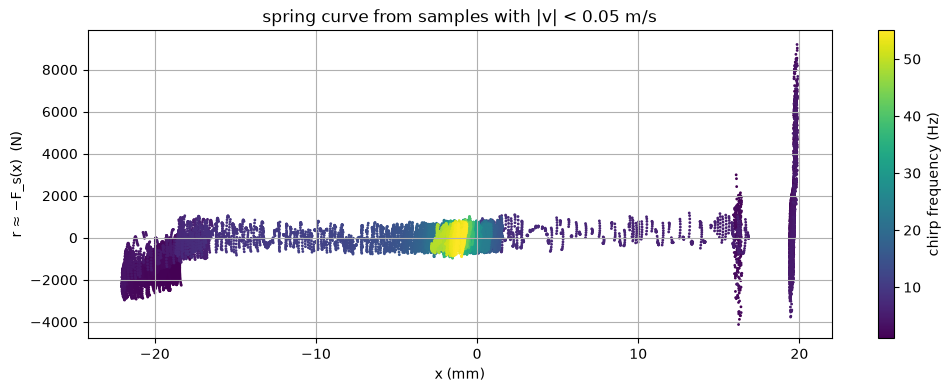

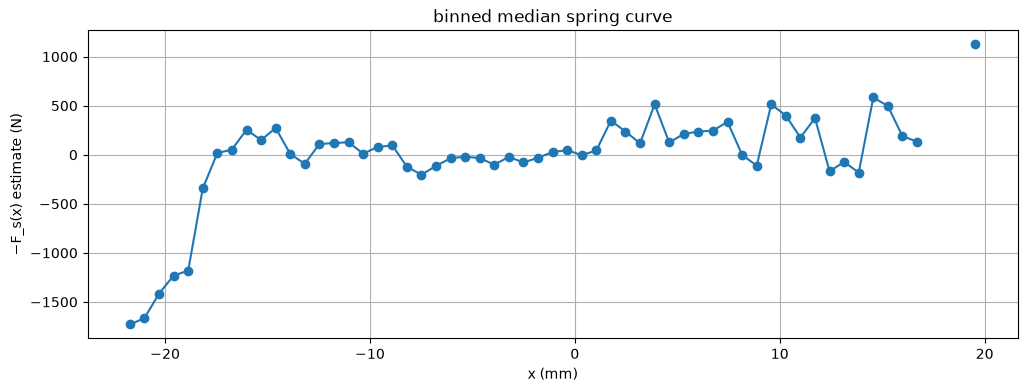

small signal stiffness near centre: k ≈ 43824 N/m  ->  resonance ≈ 4.64 Hz


In [18]:
# --- the spring seen through the near zero velocity samples ---
# When the mover is nearly at rest, the damping term vanishes and r ≈ −F_s(x). Selecting those
# samples cuts out the loop and leaves the spring curve on its own.
V_THRESH = 0.05    # m/s
near_rest = ok & (np.abs(df.v_f) < V_THRESH)

# binned median and interquartile range as a clean estimate of the spring curve. The bins are
# symmetric around zero so that bin k on the negative side mirrors bin k on the positive side.
X_BIN_LIM = np.abs(df.x_f[ok]).max()
bins = np.linspace(-X_BIN_LIM, X_BIN_LIM, 81)
xc = 0.5 * (bins[1:] + bins[:-1])
idx = np.digitize(df.x_f[near_rest], bins)
def binned(q):
    return np.array([np.percentile(df.r[near_rest][idx == k], q) if np.sum(idx == k) >= 20 else np.nan
                     for k in range(1, len(bins))])
spring_med, spring_lo, spring_hi = binned(50), binned(25), binned(75)
spring_mirror = -spring_med[::-1]        # −F_s(−x): equals spring_med if the spring is odd

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sc = ax[0].scatter(df.x_f[near_rest] * 1e3, df.r[near_rest], s=1, c=df.f_inst[near_rest], cmap="viridis")
ax[0].plot(xc * 1e3, spring_med, "k-", lw=2, label="binned median")
ax[0].fill_between(xc * 1e3, spring_lo, spring_hi, color="k", alpha=0.2, label="interquartile range")
ax[0].axvline(X_LASER_LIMIT * 1e3, color="r", ls="--", lw=1, label="laser range limit")
ax[0].set_xlabel("x (mm)"); ax[0].set_ylabel("r ≈ −F_s(x)  (N)")
ax[0].set_title(f"spring curve from samples with |v| < {V_THRESH} m/s"); ax[0].legend(loc="upper left")
plt.colorbar(sc, ax=ax[0], label="chirp frequency (Hz)")

ax[1].plot(xc * 1e3, spring_med, "k-", lw=2, label="median  −F_s(x)")
ax[1].plot(xc * 1e3, spring_mirror, "r--", lw=1.5, label="mirrored  +F_s(−x)")
ax[1].plot(xc * 1e3, spring_med - spring_mirror, "b:", lw=1.5, label="difference")
ax[1].axvline(X_LASER_LIMIT * 1e3, color="r", ls="--", lw=1)
ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_xlabel("x (mm)"); ax[1].set_ylabel("N"); ax[1].set_title("symmetry check: an odd spring gives identical curves")
ax[1].legend(loc="upper left")
plt.show()

# small signal stiffness from the central region
cen = (np.abs(xc) < 5e-3) & ~np.isnan(spring_med)
k_lin = np.polyfit(xc[cen], spring_med[cen], 1)[0]
print(f"small signal stiffness near centre: k ≈ {k_lin:.0f} N/m  ->  resonance ≈ {np.sqrt(abs(k_lin) / M) / (2*np.pi):.2f} Hz")
both = cen & ~np.isnan(spring_mirror)
print(f"symmetry: rms difference between the curve and its mirror within ±5 mm is {np.sqrt(np.nanmean((spring_med - spring_mirror)[both]**2)):.0f} N")

# --- the damping seen through the near centre samples ---
# Near x = 0 the spring force is small, so r ≈ c v and the slope of r against v is a direct estimate
# of c, independent of the Phase 2 tail fit. A loop that stays open at v = 0 signals dry friction.
X_THRESH = 3e-3    # m
near_centre = ok & (np.abs(df.x_f) < X_THRESH)
c_centre, r_offset = np.polyfit(df.v_f[near_centre], df.r[near_centre], 1)
vg = np.linspace(df.v_f[near_centre].min(), df.v_f[near_centre].max(), 2)
plt.figure(figsize=(7, 5))
plt.scatter(df.v_f[near_centre], df.r[near_centre], s=1, c=df.f_inst[near_centre], cmap="viridis")
plt.plot(vg, c_centre * vg + r_offset, "r-", lw=2, label=f"fit: c = {c_centre:.0f} N s/m")
plt.xlabel("v (m/s)"); plt.ylabel("r ≈ c v  (N)"); plt.title(f"damping line from samples with |x| < {X_THRESH*1e3:.0f} mm")
plt.colorbar(label="chirp frequency (Hz)"); plt.legend(); plt.show()
print(f"damping from the centre samples: c ≈ {c_centre:.0f} N s/m  (datasheet {C_DATASHEET:.0f})")


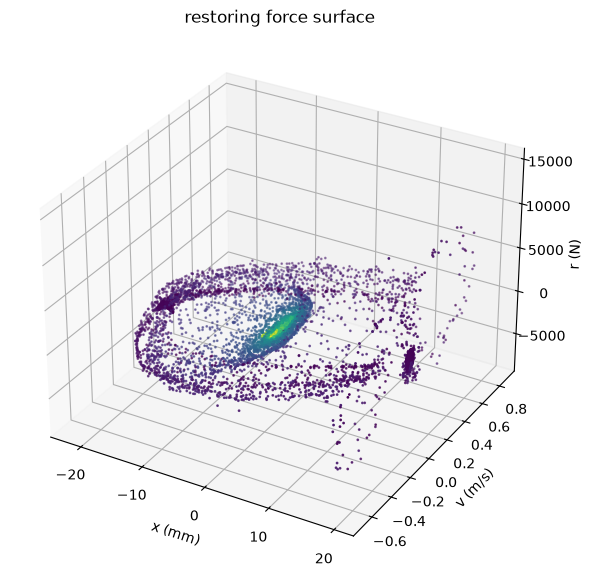

In [19]:
# --- surface over the (x, v) plane ---
from mpl_toolkits.mplot3d import Axes3D  # noqa
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
step = 40
sel = np.where(ok)[0][::step]
ax.scatter(df.x_f[sel] * 1e3, df.v_f[sel], df.r[sel], c=df.f_inst[sel], s=1, cmap="viridis")
ax.set_zlim(-r_lim, r_lim)
ax.set_xlabel("x (mm)"); ax.set_ylabel("v (m/s)"); ax.set_zlabel("r (N)")
ax.set_title("restoring force surface"); plt.show()

**Write down what you see before moving on.** The next phase needs answers to: is the curve symmetric, is there a wall and where, is the loop width proportional to velocity, do the frequency bands overlap. Keep notes here.

*Observations:*

* ...

## Phase 4: Choose the spring form and fit by least squares

**What.** Pick a mathematical shape for $F_s$ that matches Phase 3, write the equation of motion so all unknowns appear as simple multipliers, and solve in one shot.

**Two candidate forms for the spring.**

*Polynomial.* Odd powers only if the curve is symmetric:

$$F_s(x) = -\left(k_1 x + k_3 x^3 + k_5 x^5\right)$$

Simple and linear in the unknowns. It struggles with a steep wall, because polynomials do not naturally produce near vertical behaviour and tend to wiggle between data points.

*Physical magnet form.* Repulsion between two magnets falls off roughly as a power of the gap. With end gaps $g_0 \pm x$:

$$F_s(x) = a\left[\frac{1}{(g_0 - x)^n} - \frac{1}{(g_0 + x)^n}\right]$$

This produces a wall automatically as $x \to g_0$ and needs only three parameters. The price is that $g_0$ and $n$ do not appear as simple multipliers, so this form needs Phase 5's nonlinear fitter. A practical middle road is to fix $g_0$ and $n$ by eye from Phase 3, after which only $a$ is linear.

**The regression.** With the polynomial form, an offset $x_0$ approximated by an even term, and a position dependent motor constant $K_f(x) = \kappa_0 + \kappa_1 x + \kappa_2 x^2$, the equation

$$m\ddot{x} = \kappa_0 i + \kappa_1 x i + \kappa_2 x^2 i - c\dot{x} - k_1 x - k_3 x^3 - k_5 x^5$$

is linear in all coefficients. Build a matrix with those columns and call `lstsq`.

**Two practical points.**

* **Scale the variables.** Express $x$ in units of the stroke before forming powers. Otherwise $x^5$ in metres is about $10^{-9}$ while $i$ is about 1, the matrix becomes badly conditioned and the solver returns nonsense. The code below rescales automatically.
* **Report uncertainty.** From the residuals we compute standard errors of each coefficient. A coefficient whose standard error is larger than its value is not supported by the data and should be dropped.

**Why linear least squares first.** It is convex, so there is exactly one answer and it is found instantly. It costs nothing to try several spring forms and compare how well each balances the equation. This is the exploratory step; Phase 5 is the confirmatory one.

In [20]:
X_SCALE = 0.02        # m, position is normalised by this before forming powers
xs = df.x_f / X_SCALE

def build_design(xs, i, v, spring_terms, kf_terms=(0,), include_even=False):
    "Columns: K_f(x) i terms, damping, spring polynomial terms. Returns matrix and names."
    cols, names = [], []
    for p in kf_terms:
        cols.append(i * xs ** p); names.append(f"kappa{p}")
    cols.append(-v); names.append("c")
    for p in spring_terms:
        cols.append(-(xs ** p)); names.append(f"k{p}")
    if include_even:
        cols.append(-np.ones_like(xs)); names.append("F0")      # constant force term, captures an offset x0
    return np.column_stack(cols), names

def fit_and_report(A, names, y, label):
    theta, *_ = np.linalg.lstsq(A, y, rcond=None)
    resid = A @ theta - y
    dof = len(y) - A.shape[1]
    cov = (resid @ resid / dof) * np.linalg.inv(A.T @ A)
    se = np.sqrt(np.diag(cov))
    vaf = 100 * (1 - np.var(resid) / np.var(y))
    print(f"--- {label}: equation error VAF = {vaf:.2f} %, rms residual = {np.sqrt(np.mean(resid**2)):.1f} N")
    for n_, th, s_ in zip(names, theta, se):
        flag = "" if abs(th) > 2 * s_ else "   <-- not supported by data"
        print(f"  {n_:8s} = {th:12.3f} ± {s_:.3f}{flag}")
    return theta, se, resid

y = M * df.a_use.to_numpy()

In [21]:
# Model A: constant K_f, cubic spring
A_a, names_a = build_design(xs, df.i_f, df.v_f, spring_terms=(1, 3))
theta_a, se_a, resid_a = fit_and_report(A_a, names_a, y, "A: constant Kf, k1 x + k3 x^3")

# Model B: constant K_f, quintic spring, constant force term for offset
A_b, names_b = build_design(xs, df.i_f, df.v_f, spring_terms=(1, 3, 5), include_even=True)
theta_b, se_b, resid_b = fit_and_report(A_b, names_b, y, "B: constant Kf, k1..k5, offset")

# Model C: position dependent K_f, quintic spring, offset
A_c, names_c = build_design(xs, df.i_f, df.v_f, spring_terms=(1, 3, 5), kf_terms=(0, 1, 2), include_even=True)
theta_c, se_c, resid_c = fit_and_report(A_c, names_c, y, "C: Kf(x) quadratic, k1..k5, offset")

--- A: constant Kf, k1 x + k3 x^3: equation error VAF = 33.70 %, rms residual = 1026.6 N
  kappa0   =      212.532 ± 0.693
  c        =     1919.576 ± 10.174
  k1       =     -175.781 ± 12.164
  k3       =     1333.433 ± 15.404
--- B: constant Kf, k1..k5, offset: equation error VAF = 35.63 %, rms residual = 1011.1 N
  kappa0   =      211.227 ± 0.685
  c        =     1907.780 ± 10.038
  k1       =     1201.435 ± 20.039
  k3       =    -3929.847 ± 63.452
  k5       =     4003.919 ± 47.287
  F0       =       70.364 ± 2.211
--- C: Kf(x) quadratic, k1..k5, offset: equation error VAF = 38.09 %, rms residual = 991.6 N
  kappa0   =      249.944 ± 0.785
  kappa1   =      -11.077 ± 0.861
  kappa2   =     -164.926 ± 1.695
  c        =     1912.595 ± 9.849
  k1       =      799.069 ± 20.084
  k3       =    -2055.600 ± 65.648
  k5       =     2043.303 ± 51.227
  F0       =       26.531 ± 2.253


**Converting the scaled coefficients back to physical units.** A spring coefficient $k_p$ fitted against $(x/X_{\text{scale}})^p$ equals $k_p^{\text{phys}} X_{\text{scale}}^p$, so $k_p^{\text{phys}} = k_p / X_{\text{scale}}^p$ in N/m$^p$. The same holds for $\kappa_p$. The helper below does this.

In [22]:
def to_physical(theta, names):
    out = {}
    for n_, th in zip(names, theta):
        if n_[0] in "k" and n_[1:].isdigit():
            p = int(n_[1:]); out[n_ + "_phys [N/m^%d]" % p] = th / X_SCALE ** p
        elif n_.startswith("kappa"):
            p = int(n_[5:]); out[n_ + "_phys [N/(A m^%d)]" % p] = th / X_SCALE ** p
        else:
            out[n_] = th
    return pd.Series(out)

print(to_physical(theta_c, names_c).to_string())

kappa0_phys [N/(A m^0)]    2.499442e+02
kappa1_phys [N/(A m^1)]   -5.538533e+02
kappa2_phys [N/(A m^2)]   -4.123151e+05
c                          1.912595e+03
k1_phys [N/m^1]            3.995345e+04
k3_phys [N/m^3]           -2.569500e+08
k5_phys [N/m^5]            6.385322e+11
F0                         2.653066e+01


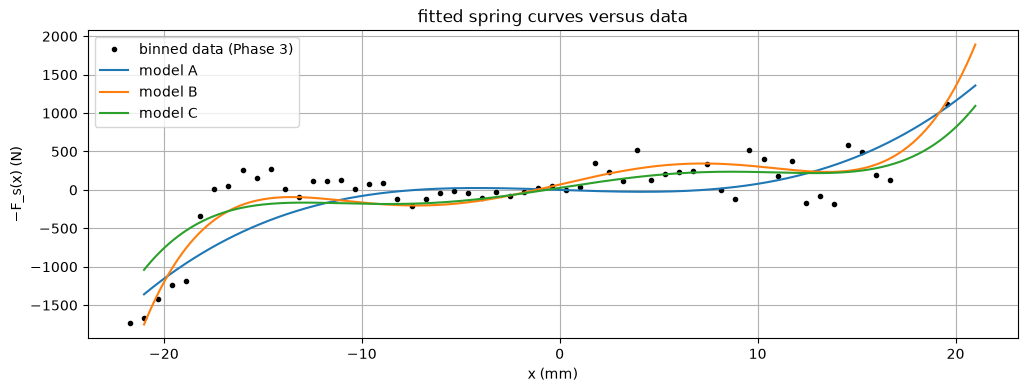

In [23]:
# --- compare the fitted spring curves with the binned Phase 3 estimate ---
xg = np.linspace(-0.021, 0.021, 400)
def spring_from_theta(theta, names, xg):
    F = np.zeros_like(xg)
    for n_, th in zip(names, theta):
        if n_[0] == "k" and n_[1:].isdigit():
            F += th * (xg / X_SCALE) ** int(n_[1:])
        if n_ == "F0":
            F += th
    return F      # this is −F_s(x), positive for positive x
plt.plot(xc * 1e3, spring_med, "ko", ms=3, label="binned data (Phase 3)")
for th, nm, lab in [(theta_a, names_a, "A"), (theta_b, names_b, "B"), (theta_c, names_c, "C")]:
    plt.plot(xg * 1e3, spring_from_theta(th, nm, xg), label=f"model {lab}")
plt.xlabel("x (mm)"); plt.ylabel("−F_s(x) (N)"); plt.legend(); plt.title("fitted spring curves versus data"); plt.show()

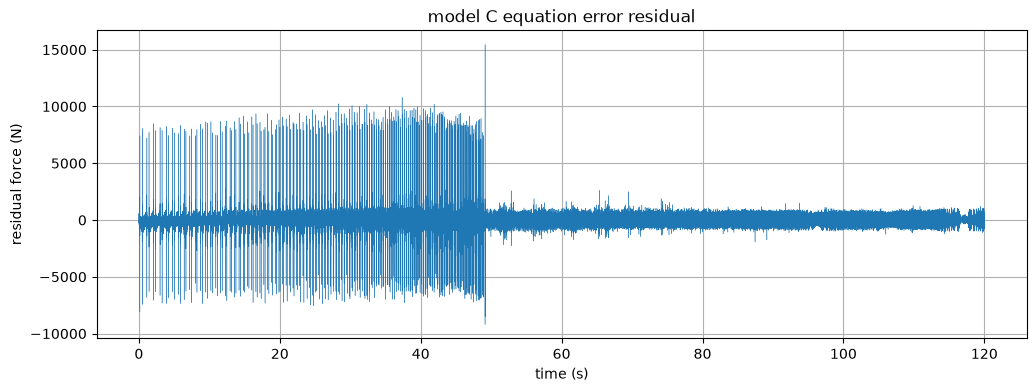

In [24]:
# --- residual of the best equation error model over time ---
plt.plot(df.t, resid_c, lw=0.3)
plt.xlabel("time (s)"); plt.ylabel("residual force (N)"); plt.title("model C equation error residual")
plt.show()

**Reading the residual.** A residual that is uniformly small and random is what we want. Residual bursts near the position extremes point at the polynomial failing to follow the wall, which would argue for the physical magnet form in Phase 5. A residual that grows with frequency points at an inertia or filter issue. A residual that grows with velocity points at damping that is not purely viscous.

## Phase 5: Simulation based refinement

**What.** Take the best parameter set from Phase 4 as a starting point. Simulate the full nonlinear model with the measured current as input, and adjust the parameters until simulated position and acceleration match the measured ones.

**How.**

1. Write the state space function $f(x, u)$ with states $(x, \dot{x})$ and input $i$.
2. Simulate with `scipy.integrate.solve_ivp`, interpolating the measured current. Use `LSODA` or `Radau` because the steep spring wall can make the equations stiff.
3. Define the error as the difference between simulated and measured position and acceleration, each divided by its own standard deviation so a millimetre and a metre per second squared count fairly.
4. Minimise with `scipy.optimize.least_squares`, starting from the Phase 4 values.

**Why this is necessary after Phase 4.** Phase 4 checks whether Newton's law balances at each instant. It does not check whether small errors accumulate into a wrong trajectory. Phase 5 does. A model can pass Phase 4 and fail Phase 5, for example if the damping is slightly wrong so the simulated resonance peak sits at the wrong height.

**Why start from Phase 4.** Nonlinear fitting only finds the nearest good answer. Starting near the truth turns a fragile procedure into a reliable one.

**Segments.** Simulating the full 120 s inside an optimiser is slow. We fit on a few segments taken from the low, middle and high frequency regions so every force term is represented, then simulate the whole run once at the end with the final parameters.

In [25]:
# --- model definition: polynomial spring with offset, quadratic K_f(x) ---
# parameter vector p = [kappa0, kappa1, kappa2, c, k1, k3, k5, F0], all in the scaled units of Phase 4
def rhs(t, s, p, i_of_t):
    x, v = s
    xs_ = x / X_SCALE
    kappa0, kappa1, kappa2, c, k1, k3, k5, F0 = p
    Kf = kappa0 + kappa1 * xs_ + kappa2 * xs_**2
    Fs = -(k1 * xs_ + k3 * xs_**3 + k5 * xs_**5 + F0)
    a_ = (Kf * i_of_t(t) - c * v + Fs) / M
    return [v, a_]

def simulate(p, t_seg, i_seg, x0, v0):
    i_of_t = interp1d(t_seg, i_seg, kind="linear", fill_value="extrapolate")
    sol = solve_ivp(rhs, (t_seg[0], t_seg[-1]), [x0, v0], t_eval=t_seg, args=(p, i_of_t),
                    method="LSODA", rtol=1e-7, atol=1e-9, max_step=1 / FS)
    x_sim, v_sim = sol.y
    a_sim = np.array([rhs(tk, [xk, vk], p, i_of_t)[1] for tk, xk, vk in zip(t_seg, x_sim, v_sim)])
    return x_sim, v_sim, a_sim

p0 = theta_c.copy()          # names_c = [kappa0, kappa1, kappa2, c, k1, k3, k5, F0]
print(dict(zip(names_c, np.round(p0, 3))))

{'kappa0': np.float64(249.944), 'kappa1': np.float64(-11.077), 'kappa2': np.float64(-164.926), 'c': np.float64(1912.595), 'k1': np.float64(799.069), 'k3': np.float64(-2055.6), 'k5': np.float64(2043.303), 'F0': np.float64(26.531)}


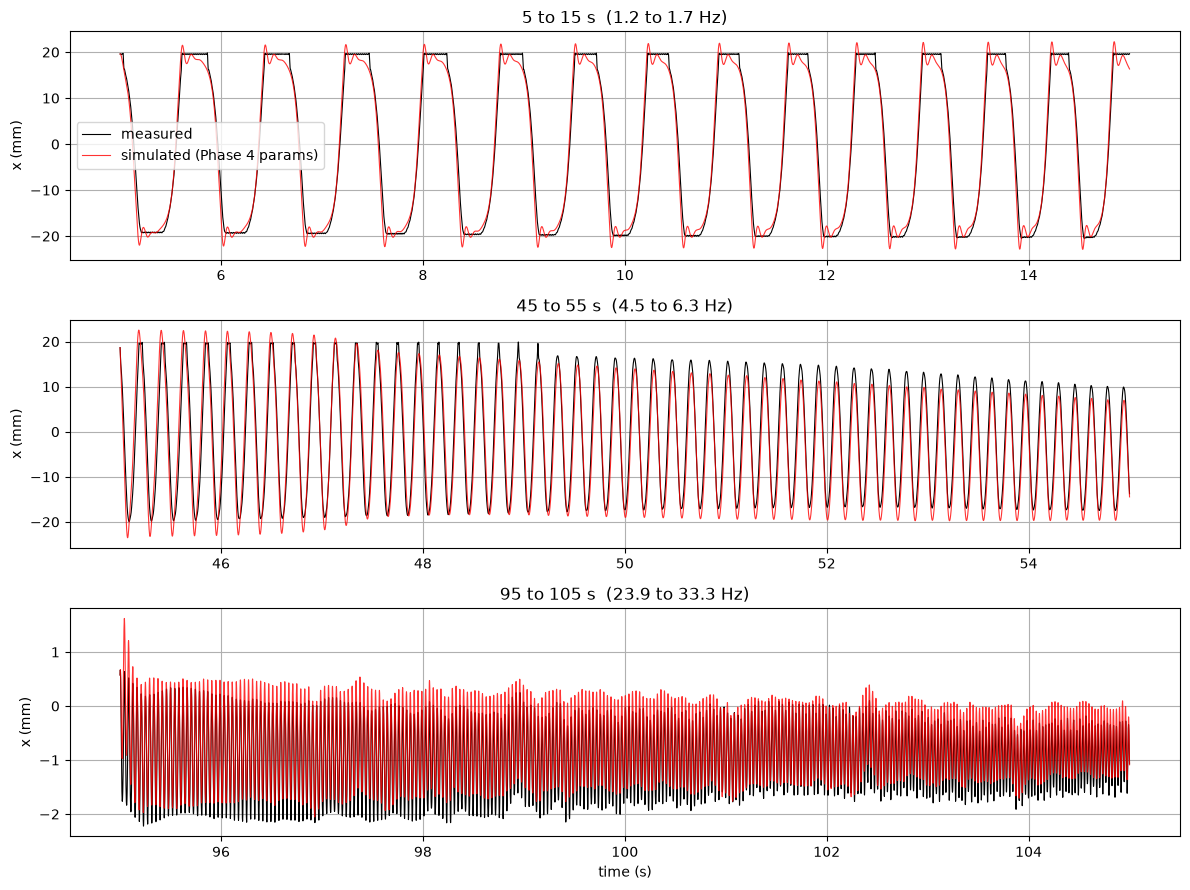

In [26]:
# --- forward simulation with the Phase 4 parameters, before any refinement ---
SEGMENTS = [(5, 15), (45, 55), (95, 105)]      # seconds: low, middle, high frequency
fig, ax = plt.subplots(len(SEGMENTS), 1, figsize=(12, 9))
for k_, (a_, b_) in enumerate(SEGMENTS):
    seg = (df.t >= a_) & (df.t <= b_)
    tt, ii = df.t[seg].to_numpy(), df.i_f[seg].to_numpy()
    x_sim, v_sim, a_sim = simulate(p0, tt, ii, df.x_f[seg].iloc[0], df.v_f[seg].iloc[0])
    ax[k_].plot(tt, df.x_f[seg] * 1e3, "k", lw=0.8, label="measured")
    ax[k_].plot(tt, x_sim * 1e3, "r", lw=0.8, alpha=0.8, label="simulated (Phase 4 params)")
    ax[k_].set_ylabel("x (mm)"); ax[k_].set_title(f"{a_} to {b_} s  ({chirp_freq(a_):.1f} to {chirp_freq(b_):.1f} Hz)")
ax[0].legend(); ax[-1].set_xlabel("time (s)"); plt.tight_layout(); plt.show()

In [ ]:
# --- output error refinement (set RUN_PHASE5 = True when ready; this takes minutes) ---
RUN_PHASE5 = True
DECIM = 4        # evaluate the cost on every 4th sample to save time

def cost(p):
    err = []
    for a_, b_ in SEGMENTS:
        seg = (df.t >= a_) & (df.t <= b_)
        tt, ii = df.t[seg].to_numpy(), df.i_f[seg].to_numpy()
        try:
            x_sim, _, a_sim = simulate(p, tt, ii, df.x_f[seg].iloc[0], df.v_f[seg].iloc[0])
        except Exception:
            return np.full(2 * (seg.sum() // DECIM + 1), 1e3)
        ex = (x_sim - df.x_f[seg].to_numpy()) / df.x_f.std()
        ea = (a_sim - df.a_use[seg].to_numpy()) / df.a_use.std()
        err.append(ex[::DECIM]); err.append(ea[::DECIM])
    return np.concatenate(err)

if RUN_PHASE5:
    scale = np.where(np.abs(p0) > 1e-6, np.abs(p0), 1.0)
    res = least_squares(cost, p0, x_scale=scale, verbose=1, max_nfev=200)
    p_final = res.x
    print(pd.DataFrame({"name": names_c, "phase4": p0, "phase5": p_final}))
else:
    p_final = p0
    print("Phase 5 skipped, carrying Phase 4 parameters forward.")

## Phase 6: Validation

**What.** Test the fitted model on data it has not been fitted on.

1. **Hold out data.** Simulate segments of this run that were not in `SEGMENTS`.
2. **New amplitude.** Load a second chirp at a different current and simulate it with the parameters from Phase 5 without refitting. A model that only reproduces the run it was fitted on is a curve fit, not a model.
3. **Metrics.** Report the variance accounted for,

$$\text{VAF} = 100\left(1 - \frac{\operatorname{var}(y_{\text{meas}} - y_{\text{sim}})}{\operatorname{var}(y_{\text{meas}})}\right)\ \%$$

for position and acceleration separately.

4. **Residual plots.** Random looking residuals mean the model has captured the structure. Residuals that grow at a certain frequency or amplitude tell you exactly what is missing and where.
5. **Small signal check.** From a low amplitude run, compute a frequency response with Welch's method and overlay the frequency response of the nonlinear model linearised at the centre.

**Why validation on a different amplitude specifically.** The system is nonlinear. A different amplitude reaches different parts of the spring curve and different velocities. Predicting it correctly is the only real evidence that the spring and damping shapes are right rather than tuned to one dataset.

In [ ]:
def vaf(y_meas, y_sim):
    return 100 * (1 - np.var(y_meas - y_sim) / np.var(y_meas))

HOLDOUT = [(25, 35), (70, 80), (110, 118)]
for a_, b_ in HOLDOUT:
    seg = (df.t >= a_) & (df.t <= b_)
    tt, ii = df.t[seg].to_numpy(), df.i_f[seg].to_numpy()
    x_sim, _, a_sim = simulate(p_final, tt, ii, df.x_f[seg].iloc[0], df.v_f[seg].iloc[0])
    print(f"holdout {a_}-{b_} s ({chirp_freq(a_):.1f} to {chirp_freq(b_):.1f} Hz): "
          f"VAF position {vaf(df.x_f[seg].to_numpy(), x_sim):.1f} %, VAF acceleration {vaf(df.a_use[seg].to_numpy(), a_sim):.1f} %")

In [ ]:
# --- full run simulation and residuals with the final parameters (takes a while) ---
RUN_FULL = True
if RUN_FULL:
    x_sim, v_sim, a_sim = simulate(p_final, df.t.to_numpy(), df.i_f.to_numpy(), df.x_f.iloc[0], df.v_f.iloc[0])
    fig, ax = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
    ax[0].plot(df.t, df.x_f * 1e3, "k", lw=0.3, label="measured"); ax[0].plot(df.t, x_sim * 1e3, "r", lw=0.3, alpha=0.7, label="simulated")
    ax[0].set_ylabel("x (mm)"); ax[0].legend()
    ax[1].plot(df.t, (x_sim - df.x_f) * 1e3, lw=0.3, color="k"); ax[1].set_ylabel("x residual (mm)")
    ax[2].plot(df.t, df.a_use, "k", lw=0.3, label=f"measured ({A_USE})"); ax[2].plot(df.t, a_sim, "r", lw=0.3, alpha=0.7, label="simulated")
    ax[2].set_ylabel("a (m/s²)"); ax[2].legend()
    ax[3].plot(df.t, a_sim - df.a_use, lw=0.3, color="k"); ax[3].set_ylabel("a residual (m/s²)"); ax[3].set_xlabel("time (s)")
    secax = ax[0].secondary_xaxis("top", functions=(chirp_freq, time_at_freq))
    secax.set_xlabel("instantaneous frequency (Hz)")
    plt.show()
    print(f"full run VAF position {vaf(df.x_f.to_numpy(), x_sim):.1f} %, acceleration {vaf(df.a_use.to_numpy(), a_sim):.1f} %")

In [ ]:
# --- validation on a second run at a different amplitude ---
VALIDATION_CSV = None     # e.g. "voice_coil_log_chirp_2_0A_....csv"
if VALIDATION_CSV:
    raw2 = pd.read_csv(VALIDATION_CSV); raw2.columns = [c.strip() for c in raw2.columns]
    raw2 = raw2.iloc[1:].reset_index(drop=True)
    t2 = raw2["time_s"].to_numpy(); i2 = lp(raw2["actual_current_A"].to_numpy()); x2 = lp(raw2["position_mm"].to_numpy() * 1e-3)
    v2 = np.gradient(x2, 1 / FS)
    x_sim2, _, _ = simulate(p_final, t2, i2, x2[0], v2[0])
    plt.plot(t2, x2 * 1e3, "k", lw=0.3, label="measured"); plt.plot(t2, x_sim2 * 1e3, "r", lw=0.3, alpha=0.7, label="predicted, no refit")
    plt.xlabel("time (s)"); plt.ylabel("x (mm)"); plt.legend(); plt.show()
    print(f"validation VAF position: {vaf(x2, x_sim2):.1f} %")

**Small signal check.** Around the centre the model linearises to

$$G(s) = \frac{X(s)}{I(s)} = \frac{\kappa_0}{m s^2 + c s + k_1^{\text{phys}}}$$

On a low amplitude run the measured frequency response, estimated with Welch's method (`scipy.signal.csd` divided by `scipy.signal.welch`), should follow this curve. The cell below computes both once a low amplitude CSV is available.

In [ ]:
LOWAMP_CSV = None
if LOWAMP_CSV:
    raw3 = pd.read_csv(LOWAMP_CSV); raw3.columns = [c.strip() for c in raw3.columns]
    i3 = raw3["actual_current_A"].to_numpy(); x3 = raw3["position_mm"].to_numpy() * 1e-3
    f, Pii = signal.welch(i3, FS, nperseg=8192)
    _, Pxi = signal.csd(i3, x3, FS, nperseg=8192)
    _, coh = signal.coherence(i3, x3, FS, nperseg=8192)
    H_meas = Pxi / Pii
    kappa0, c_fit, k1_phys = p_final[0], p_final[3], p_final[4] / X_SCALE
    w = 2 * np.pi * f
    H_mod = kappa0 / (M * (1j * w) ** 2 + c_fit * 1j * w + k1_phys)
    fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    ax[0].loglog(f, np.abs(H_meas) * 1e3, label="measured"); ax[0].loglog(f, np.abs(H_mod) * 1e3, "--", label="model linearised"); ax[0].set_ylabel("|X/I| (mm/A)"); ax[0].legend()
    ax[1].semilogx(f, np.degrees(np.angle(H_meas))); ax[1].semilogx(f, np.degrees(np.angle(H_mod)), "--"); ax[1].set_ylabel("phase (deg)")
    ax[2].semilogx(f, coh); ax[2].set_ylabel("coherence"); ax[2].set_xlabel("frequency (Hz)"); ax[2].set_xlim(0.5, 100)
    plt.show()

## Phase 7: Next experiments

The current run supports Phases 0 to 5 by itself. The following runs would strengthen the result.

1. **Low amplitude chirp (1 to 2 A, 1 to 55 Hz).** Keeps the mover away from the wall so the resonance shows cleanly. Gives the small signal stiffness and the linear check in Phase 6.
2. **Quasi static current sweep.** Slowly ramp current up and down and log position. With nothing moving fast, $K_f i = -F_s(x)$ directly. This is the cleanest possible spring measurement and an independent check on Phase 3. Ramping both directions also reveals hysteresis.
3. **Several amplitudes.** Two or three chirps at different currents map how the effective stiffness and $K_f$ change with amplitude and provide validation data.
4. **Log the coil voltage.** The back EMF route in Phase 2 is one of the strongest cross checks available and needs the coil terminal voltage as a column in the CSV.

## Summary

| Phase | Uses | Produces | Risk if skipped |
|---|---|---|---|
| 0 Inspect | Raw CSV | Clean SI data, tracking check documented | Unit errors propagate everywhere |
| 1 Condition | Clean data | Aligned $x, \dot{x}, \ddot{x}, i$ | Biased damping from time misalignment |
| 2 Motor constant | High frequency tail, coil voltage | $K_f$ two ways | Wrong scale on every force |
| 3 Restoring force | Whole run | Picture of spring and damping | Wrong model form chosen blindly |
| 4 Regression | Chosen form | First parameter set with uncertainties | Nonlinear fit has no good start |
| 5 Simulation fit | Phase 4 values | Final parameters | Instant balance may not reproduce trajectories |
| 6 Validation | New data | Evidence the model is right | Curve fit mistaken for a model |
| 7 Experiments | Actuator | Cleaner spring, linear check | Nonlinearity untested |